# Option B Exploration

This notebook contains the exploration component for Option B, due the week after the main notebook. Choose something related to the topics covered in the main notebook and build something creative or interesting.

_For this notebook some helpful **starting points** for the extension include:_

* **Stereo view synthesis:** Start from a **dense disparity map** (e.g. the motorcycle stereo pair in Part 2) and aim to **draw the scene again** as if a **second, shifted camera** had taken the picture- not just a false-color disparity plot.

* **Metric depth:** Turn disparities into **metric depth** with $\text{depth} = \frac{B \cdot f}{\text{disparity}}$ using a plausible **baseline** and **focal length**, and stabilize the denominator when disparity is tiny or noisy.

* **Calibration & lifting:** Use the camera **intrinsics** ($3 \times 3$ matrix $K$) together with disparity and baseline to **lift pixels from the image into 3D** in the original camera’s coordinate frame.

* **Virtual camera motion:** Describe how the new camera sits relative to the first with a **rigid motion**—a **rotation** and **translation**—and **move every 3D point** into that new camera’s frame before drawing.

* **Rendering:** **Project** those 3D points back onto a **fresh image grid** with intrinsics suited to the new view, producing the **rerendered photograph** (including how you handle resolution, bounds, and empty pixels).

For more detailed instructions, please see the [Project 2 Guidelines](https://docs.google.com/document/d/1_w5RefFChBW3IdvhiCvtLgPGkIDNeWNKhVrLjKPL2Fw/edit?usp=sharing)


## Review of current methods (10 points)
Once you’ve selected a topic or project idea, explore the literature space. Has there been academic research on this topic? Are there tutorials online, software packages, or libraries?

Select at least 5 resources (youtube videos, papers, tutorials, opensource software, libraries, etc) and provide a short description (2-3 sentences) below:

* Source 1: Hartley, R. & Zisserman, A. (2003). "Multiple View Geometry in Computer Vision," 2nd Edition, Cambridge University Press. https://www.robots.ox.ac.uk/~vgg/hzbook/
This explains the Direct Linear Transform (DLT) method for fitting a homography. I used it to understand how the linear system is set up and then implemented my own fit_homography_matrix function based on that idea.

* Source 2: Brown, M. & Lowe, D. G. (2007). "Automatic Panoramic Image Stitching using Invariant Features," International Journal of Computer Vision, 74(1), 59-73. https://link.springer.com/article/10.1007/s11263-006-0002-3
This paper shows how homographies are used in real panorama stitching systems. It helped me understand why homography is preferred over affine in many cases and motivated my comparison between the two.

* Source 3:Fischler, M. A. & Bolles, R. C. (1981). "Random Sample Consensus," Communications of the ACM, 24(6), 381-395. https://dl.acm.org/doi/10.1145/358669.358692
This paper describes the RANSAC algorithm. I used it to implement my homography RANSAC with 4-point sampling.

* Source 4: OpenCV Documentation — findHomography. https://docs.opencv.org/4.x/d9/d0c/group__calib3d.html
This documentation explains how homography estimation is implemented in practice. It helped guide my implementation and understanding of robustness.

* Source 5: scikit-image documentation — Geometric Transformations. https://scikit-image.org/docs/stable/api/skimage.transform.html
This page documents the geometric transformation functions in scikit-image, which is the library I used to warp images for the panorama. It explained how the warp function maps pixels using a 3x3 transformation matrix, which I needed to make my homography output work correctly with the existing pipeline.

## Code (70 points)
We expect you to write code for this project (CS131 is, after all, a CS class 🙂). You may implement algorithms from scratch or expand on algorithms from this notebook if you would like, but using other libraries or other open-source software in a creative way is also sufficient.

You are not required to develop your code in this notebook! Feel free to create your own jupyter notebook for the project or write code in your environment of choice! (Jupyter notebook or google colab are good starting options)!


In [1]:
import os

if not os.path.exists("CS131_release"):
    !git clone https://github.com/aarav06-bit/CS131_release.git

%cd /content/CS131_release/spring_2026/project2_release/option_B

/content/CS131_release/spring_2026/project2_release/option_B


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
from skimage.feature import corner_peaks
from scipy.spatial.distance import cdist
from scipy.ndimage import convolve
from skimage import filters
from skimage import transform
from utils import pad, unpad, get_output_space, warp_image, plot_matches, describe_keypoints



In [3]:
def harris_corners(img, window_size=3, k=0.04):

    H, W = img.shape
    window = np.ones((window_size, window_size))

    response = np.zeros((H, W))
    dx = filters.sobel_v(img)
    dy = filters.sobel_h(img)

    Ixx = dx * dx
    Iyy = dy * dy
    Ixy = dx * dy

    Sxx = convolve(Ixx, window, mode='constant', cval=0)
    Syy = convolve(Iyy, window, mode='constant', cval=0)
    Sxy = convolve(Ixy, window, mode='constant', cval=0)

    det_M = Sxx * Syy - Sxy * Sxy
    trace_M = Sxx + Syy

    response = det_M - k * (trace_M ** 2)

    return response

def simple_descriptor(patch):

    feature = []

    mean = np.mean(patch)
    std = np.std(patch)
    if std == 0:
        std = 1
    feature = ((patch - mean) / std).flatten()

    return feature

def match_descriptors(desc1, desc2, threshold=0.5):

    matches = []

    M = desc1.shape[0]
    dists = cdist(desc1, desc2)

    for i in range(M):
        row = dists[i]
        sorted_indices = np.argsort(row)
        closest_idx = sorted_indices[0]
        second_closest_idx = sorted_indices[1]

        if row[closest_idx] / row[second_closest_idx] < threshold:
            matches.append([i, closest_idx])

    matches = np.asarray(matches)

    return matches


In [4]:
def fit_affine_matrix(p1, p2, to_pad=True):
    assert (p1.shape[0] == p2.shape[0])
    if to_pad:
        p1 = pad(p1)
        p2 = pad(p2)
    H, _, _, _ = np.linalg.lstsq(p2, p1, rcond=None)
    H[:, 2] = np.array([0, 0, 1])
    return H

In [5]:
def ransac(keypoints1, keypoints2, matches, n_iters=200, threshold=20):
    orig_matches = matches.copy()
    matches = matches.copy()
    N = matches.shape[0]
    n_samples = max(3, int(N * 0.2))
    matched1 = pad(keypoints1[matches[:, 0]])
    matched2 = pad(keypoints2[matches[:, 1]])
    max_inliers = np.zeros(N, dtype=bool)
    n_inliers = 0
    for i in range(n_iters):
        np.random.shuffle(matches)
        samples = matches[:n_samples]
        unique_pts = np.unique(keypoints2[samples[:, 1]], axis=0)
        if len(unique_pts) < 3:
            continue
        sample1 = pad(keypoints1[samples[:, 0]])
        sample2 = pad(keypoints2[samples[:, 1]])
        if np.linalg.matrix_rank(sample2) < 3:
            continue
        H = fit_affine_matrix(sample1, sample2, to_pad=False)
        predicted = matched2 @ H
        distances = np.linalg.norm(predicted - matched1, axis=1)
        inliers = distances < threshold
        n_curr_inliers = np.sum(inliers)
        if n_curr_inliers > n_inliers:
            n_inliers = n_curr_inliers
            max_inliers = inliers
    if max_inliers.sum() >= 3:
        H = fit_affine_matrix(matched1[max_inliers], matched2[max_inliers], to_pad=False)
    else:
        H = np.eye(3)
    return H, orig_matches[max_inliers]

In [6]:
def linear_blend(img1_warped, img2_warped):
    out_H, out_W = img1_warped.shape
    img1_mask = (img1_warped != 0)
    img2_mask = (img2_warped != 0)
    right_margin = out_W - np.argmax(np.fliplr(img1_mask)[out_H//2, :].reshape(1, out_W), 1)[0]
    left_margin = np.argmax(img2_mask[out_H//2, :].reshape(1, out_W), 1)[0]
    weights1 = np.ones((out_H, out_W))
    weights1[:, left_margin:right_margin] = np.linspace(1, 0, right_margin - left_margin)
    weights1[:, right_margin:] = 0
    weights2 = np.zeros((out_H, out_W))
    weights2[:, left_margin:right_margin] = np.linspace(0, 1, right_margin - left_margin)
    weights2[:, right_margin:] = 1
    weights1 = weights1 * img1_mask
    weights2 = weights2 * img2_mask
    merged = img1_warped * weights1 + img2_warped * weights2
    return merged

In [7]:
def fit_homography_matrix(p1, p2):
    N = p1.shape[0]
    A = np.zeros((2 * N, 9))
    for i in range(N):
        x, y = p2[i]
        x_prime, y_prime = p1[i]
        A[2*i]     = [-x, -y, -1,  0,  0,  0, x*x_prime, y*x_prime, x_prime]
        A[2*i + 1] = [ 0,  0,  0, -x, -y, -1, x*y_prime, y*y_prime, y_prime]
    _, _, V = np.linalg.svd(A)
    H = V[-1].reshape(3, 3)
    return H / H[2, 2]

In [8]:
def ransac_homography(keypoints1, keypoints2, matches, n_iters=500, threshold=5):
    matches = matches.copy()
    N = matches.shape[0]
    pts1 = keypoints1[matches[:, 0]][:, ::-1].astype(np.float64)
    pts2 = keypoints2[matches[:, 1]][:, ::-1].astype(np.float64)
    max_inliers = np.zeros(N, dtype=bool)
    n_inliers = 0
    for _ in range(n_iters):
        if N < 4:
            break
        idx = np.random.choice(N, 4, replace=False)
        unique_pts = np.unique(pts2[idx], axis=0)
        if len(unique_pts) < 4:
            continue
        H = fit_homography_matrix(pts1[idx], pts2[idx])
        pts2_h = np.hstack([pts2, np.ones((N, 1))])
        projected = (H @ pts2_h.T).T
        denom = projected[:, 2:3]
        if np.any(np.abs(denom) < 1e-10):
            continue
        projected = projected[:, :2] / denom
        distances = np.linalg.norm(projected - pts1, axis=1)
        inliers = distances < threshold
        if inliers.sum() > n_inliers:
            n_inliers = inliers.sum()
            max_inliers = inliers
    if n_inliers >= 4:
        H = fit_homography_matrix(pts1[max_inliers], pts2[max_inliers])
    else:
        H = np.eye(3)
    return H

In [9]:
def stitch_with_affine(img1, img2):
    if len(img1.shape) == 3:
        img1 = color.rgb2gray(img1)
    if len(img2.shape) == 3:
        img2 = color.rgb2gray(img2)
    img1 = transform.resize(img1, (img1.shape[0] // 4, img1.shape[1] // 4), anti_aliasing=True)
    img2 = transform.resize(img2, (img2.shape[0] // 4, img2.shape[1] // 4), anti_aliasing=True)
    kpts1 = corner_peaks(harris_corners(img1), threshold_rel=0.05, exclude_border=8)
    kpts2 = corner_peaks(harris_corners(img2), threshold_rel=0.05, exclude_border=8)
    desc1 = describe_keypoints(img1, kpts1, desc_func=simple_descriptor, patch_size=16)
    desc2 = describe_keypoints(img2, kpts2, desc_func=simple_descriptor, patch_size=16)
    matches = match_descriptors(desc1, desc2, threshold=0.7)
    H, _ = ransac(kpts1, kpts2, matches, threshold=2)
    output_shape, offset = get_output_space(img1, [img2], [H])
    img1_warped = warp_image(img1, np.eye(3), output_shape, offset)
    img1_warped[img1_warped == -1] = 0
    img2_warped = warp_image(img2, H, output_shape, offset)
    img2_warped[img2_warped == -1] = 0
    return linear_blend(img1_warped, img2_warped)

In [10]:
def stitch_with_homography(img1, img2):
    if len(img1.shape) == 3:
        img1 = color.rgb2gray(img1)
    if len(img2.shape) == 3:
        img2 = color.rgb2gray(img2)
    img1 = transform.resize(img1, (img1.shape[0] // 4, img1.shape[1] // 4), anti_aliasing=True)
    img2 = transform.resize(img2, (img2.shape[0] // 4, img2.shape[1] // 4), anti_aliasing=True)
    kpts1 = corner_peaks(harris_corners(img1), threshold_rel=0.05, exclude_border=8)
    kpts2 = corner_peaks(harris_corners(img2), threshold_rel=0.05, exclude_border=8)
    desc1 = describe_keypoints(img1, kpts1, desc_func=simple_descriptor, patch_size=16)
    desc2 = describe_keypoints(img2, kpts2, desc_func=simple_descriptor, patch_size=16)
    matches = match_descriptors(desc1, desc2, threshold=0.7)
    H_xy = ransac_homography(kpts1, kpts2, matches, threshold=5)
    H_yx = np.array([[H_xy[1, 1], H_xy[1, 0], H_xy[1, 2]],
                     [H_xy[0, 1], H_xy[0, 0], H_xy[0, 2]],
                     [H_xy[2, 1], H_xy[2, 0], H_xy[2, 2]]]).T
    output_shape, offset = get_output_space(img1, [img2], [H_yx])
    img1_warped = warp_image(img1, np.eye(3), output_shape, offset)
    img1_warped[img1_warped == -1] = 0
    img2_warped = warp_image(img2, H_yx, output_shape, offset)
    img2_warped[img2_warped == -1] = 0
    return linear_blend(img1_warped, img2_warped)

In [11]:
image_sets = [
    ("/content/goku1.jpg",    "/content/goku2.jpg"),
    ("/content/blanket1.jpg", "/content/blanket2.jpg"),
    ("/content/hallway1.jpg", "/content/hallway2.jpg"),
]

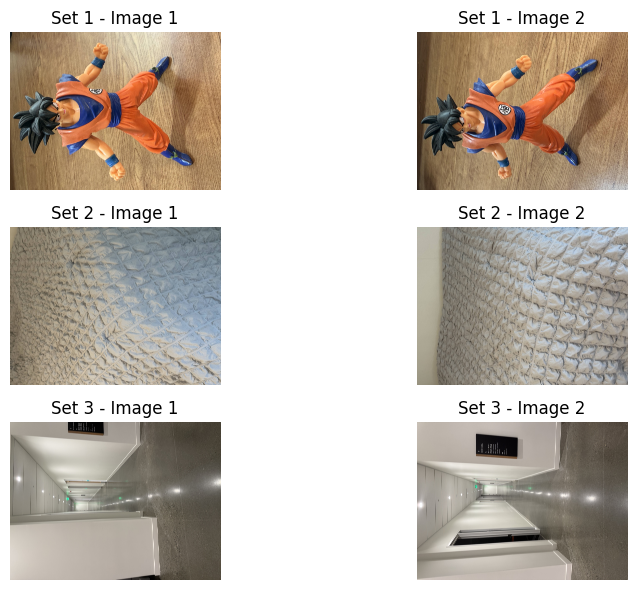

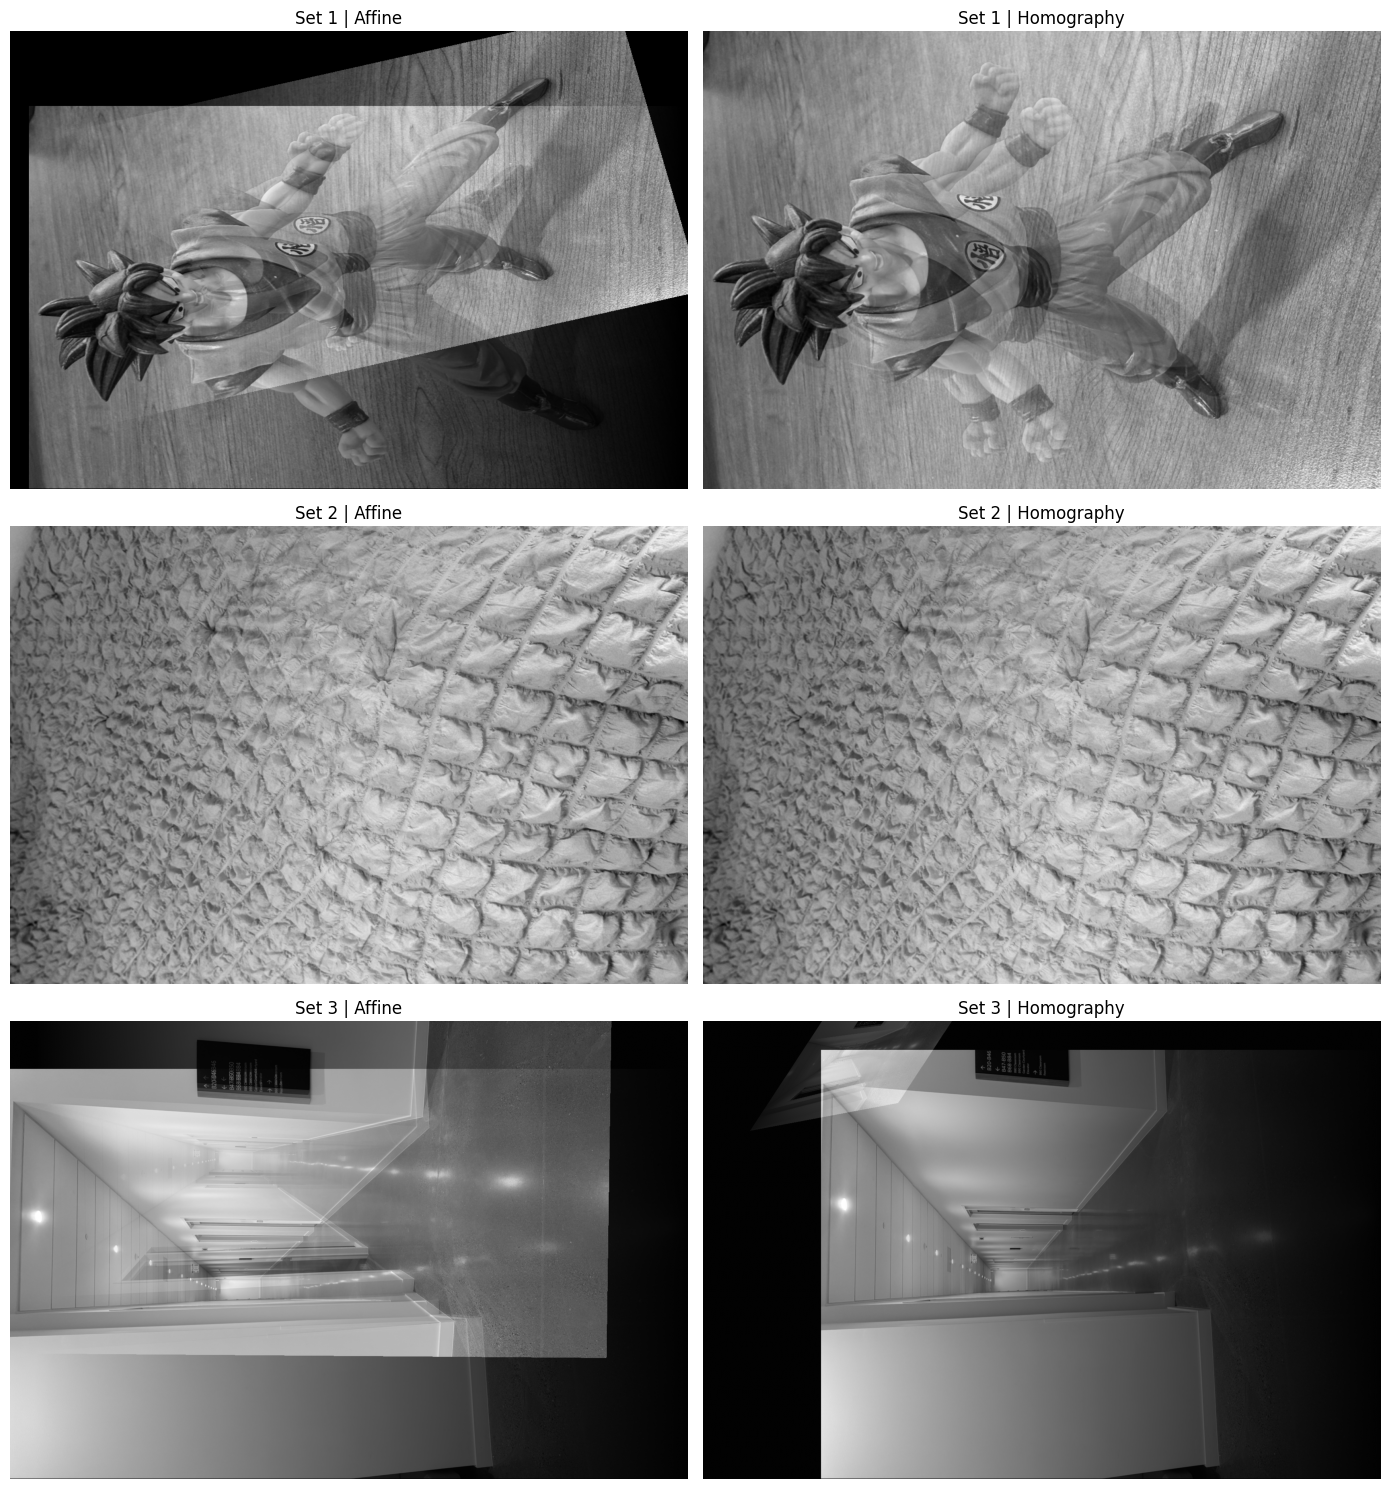

In [14]:
def show_original_images(image_sets):
    plt.figure(figsize=(10, 6))

    for i, (p1, p2) in enumerate(image_sets):
        img1 = io.imread(p1)
        img2 = io.imread(p2)

        plt.subplot(len(image_sets), 2, 2*i + 1)
        plt.imshow(img1)
        plt.title(f"Set {i+1} - Image 1")
        plt.axis('off')

        plt.subplot(len(image_sets), 2, 2*i + 2)
        plt.imshow(img2)
        plt.title(f"Set {i+1} - Image 2")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
show_original_images(image_sets)

fig, axes = plt.subplots(len(image_sets), 2, figsize=(14, 5 * len(image_sets)))

for i, (p1, p2) in enumerate(image_sets):
    img1 = io.imread(p1)
    img2 = io.imread(p2)

    np.random.seed(131)
    pano_affine = stitch_with_affine(img1, img2)

    np.random.seed(131)
    pano_homography = stitch_with_homography(img1, img2)

    axes[i, 0].imshow(pano_affine, cmap='gray', aspect='auto')
    axes[i, 0].set_title(f"Set {i+1} | Affine")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(pano_homography, cmap='gray', aspect='auto')
    axes[i, 1].set_title(f"Set {i+1} | Homography")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.savefig("affine_vs_homography.png")
plt.show()

## Writeup (20 points)

An explanation of what you did, and how it relates to the topic of choice. (~200 words) Please attach any images, figures, etc.

_You may also add a link to your writeup if that is easier!_

For this exploration, I compared two approaches for panorama stitching which are the affine transformation used in Project 2 and a homography-based transformation. The affine model has 6 parameters and assumes parallel lines remain parallel, which works well under limited camera motion. A homography has 8 parameters and can capture full perspective effects, making it more suitable for real-world scenes with viewpoint changes.

I implemented the homography using the Direct Linear Transform (DLT), where each keypoint correspondence contributes constraints to a linear system that is solved using SVD. I also adapted RANSAC to use 4-point samples per iteration, since a homography requires four correspondences to estimate, compared to three for affine.

I evaluated both methods on three image pairs: a Goku figure, a blanket texture, and a hallway. For the Goku pair, the affine result showed visible ghosting and a black gap, while the homography produced a cleaner and better-aligned image, indicating the presence of perspective effects. For the blanket pair, both methods gave nearly identical results, suggesting the scene is approximately planar with minimal viewpoint change. For the hallway, the homography better preserved the structure of the scene, particularly along perspective lines, while affine showed slight misalignment.

These results show that affine transformations are sufficient for simple or near-planar scenes, but homographies provide a more flexible and accurate model when perspective effects are present. However, homographies require more parameters to estimate, making them more sensitive to noisy matches and requiring stronger filtering through RANSAC.